In [5]:
import pandas as pd

In [3]:
import os
os.getcwd()

'c:\\Users\\jsjin\\OneDrive\\Documents\\github\\mit_healthcare_dataset\\notebooks\\exploration'

In [28]:
df = pd.read_csv("C:\\Users\\jsjin\\OneDrive\\Documents\\github\\mit_healthcare_dataset\\data\\raw\\modified_healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,19,Female,AB+,Infections,2024-01-31,Matthew Smith,Northwestern Memorial Hospital,Blue Cross,2212.272701,328,Emergency,2024-02-07,Azithromycin,Normal,7
1,Leslie Terry,15,Female,B-,Flu,2019-08-20,Samantha Davies,UI Health (University of Illinois Hospital),UnitedHealthcare,3185.161388,265,Emergency,2019-08-22,Tamiflu,Abnormal,2
2,Danny Smith,50,Female,A+,Cancer,2022-09-22,Tiffany Mitchell,UI Health (University of Illinois Hospital),Blue Cross,72055.214065,205,Elective,2022-10-30,Cisplatin,Inconclusive,38
3,Andrew Watts,24,Female,O+,Asthma,2020-11-18,Kevin Wells,UI Health (University of Illinois Hospital),Aetna,4092.601229,450,Elective,2020-11-19,Prednisone,Normal,1
4,Adrienne Bell,80,Female,A+,Heart Disease,2022-09-19,Kathleen Hanna,Northwestern Memorial Hospital,Cigna,47985.660254,458,Routine,2022-10-27,Beta-blockers,Inconclusive,38


In [9]:
df["Age"].min()

np.int64(5)

In [49]:
bins = [0, 17, 25, 45, 65, 100]
labels = ["Youth", "Young Adult", "Adult", "Mature Adult", "Senior"]
df ["age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [50]:
df["age_group"].value_counts()

age_group
Mature Adult    17900
Adult           14291
Senior          13285
Youth            5752
Young Adult      4272
Name: count, dtype: int64

In [51]:
len(df)

55500

In [52]:
df["age_group"].value_counts().sum()

np.int64(55500)

In [53]:
df[df["age_group"].isna()]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,age_group


In [54]:
df.loc[df["age_group"].isna(), "Age"].unique()

array([], dtype=int64)

In [21]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib
matplotlib.use('Agg')  # Ensuring Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switch backend if only plt module is used
%matplotlib inline
import seaborn as sns
from datetime import datetime

In [22]:
# For predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [23]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

**Data Loading & Preprocessing**

In [55]:
# Display basic info about the dataset
print('Dataset loaded. Shape:', df.shape)
print('Columns:', df.columns.tolist())

# Convert date columns to datetime objects. We assume `Date of Admission` and `Discharge Date` should be dates.
date_columns = ['Date of Admission', 'Discharge Date']
for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    except Exception as e:
        print(f'Error converting {col}:', e)

# Check conversion
print('Data types after date conversion:')
print(df.dtypes)

Dataset loaded. Shape: (55500, 17)
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay', 'age_group']
Data types after date conversion:
Name                          object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type                object
Discharge Date        datetime64[ns]
Medication                    object
Test Results                  object
Length of Stay                 int64
age_group                   category
dtype: object


Data Cleaning and Preprocessing

In [56]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# For demonstration, we are dropping rows with missing Billing Amount or Length of Stay
df = df.dropna(subset=['Billing Amount', 'Length of Stay'])

# Other minor cleaning: Trim whitespace from string columns
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].str.strip()

# Display cleaned dataset summary
print('Data cleaned. Shape now:', df.shape)

Missing values in each column:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
age_group             0
dtype: int64
Data cleaned. Shape now: (55500, 17)


Exploratory Data Analysis

Numeric columns: ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']


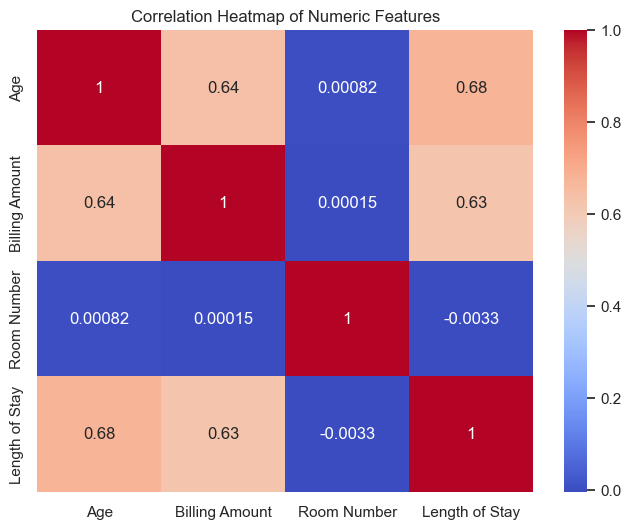

In [57]:
# Analyzing numeric columns (make sure there are at least four numeric columns for the correlation heatmap)
numeric_df = df.select_dtypes(include=[np.number])
print('Numeric columns:', numeric_df.columns.tolist())

if numeric_df.shape[1] >= 4:
    # Correlation heatmap
    corr = numeric_df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print('Not enough numeric columns for correlation heatmap.')

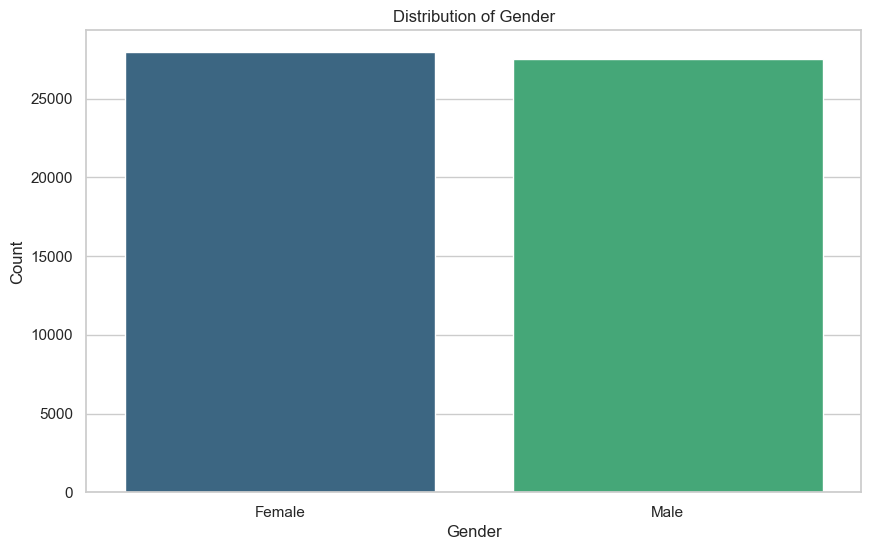

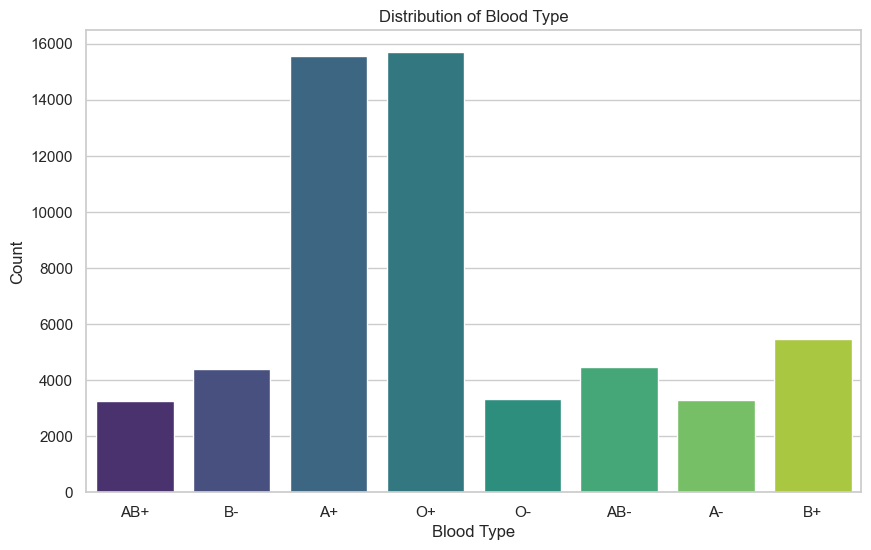

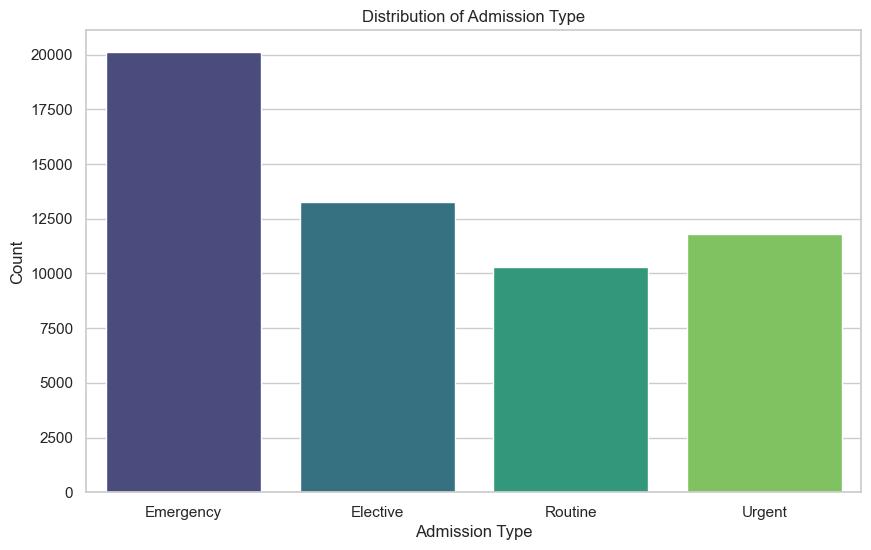

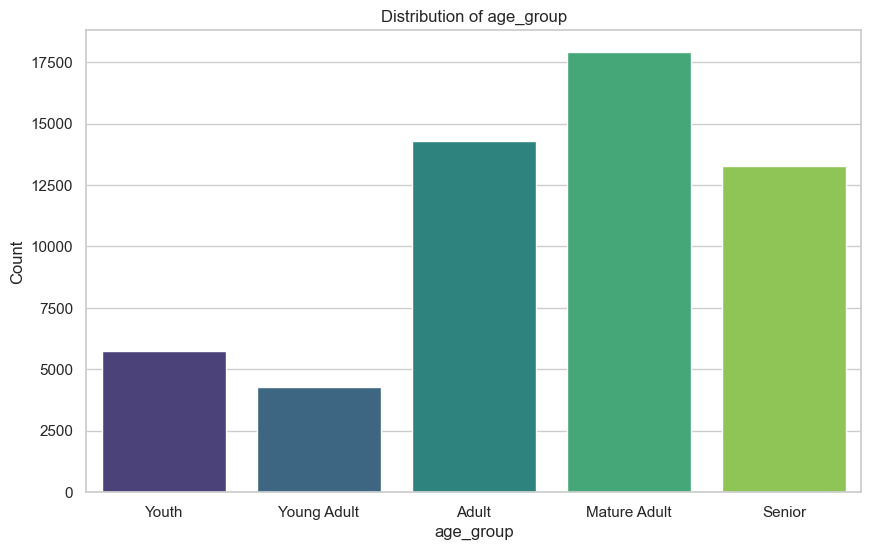

In [59]:
# Visualization for categorical variables: Gender, Blood Type, and Admission Type
categorical_cols = ['Gender', 'Blood Type', 'Admission Type', 'age_group']

for col in categorical_cols:
    plt.figure()
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

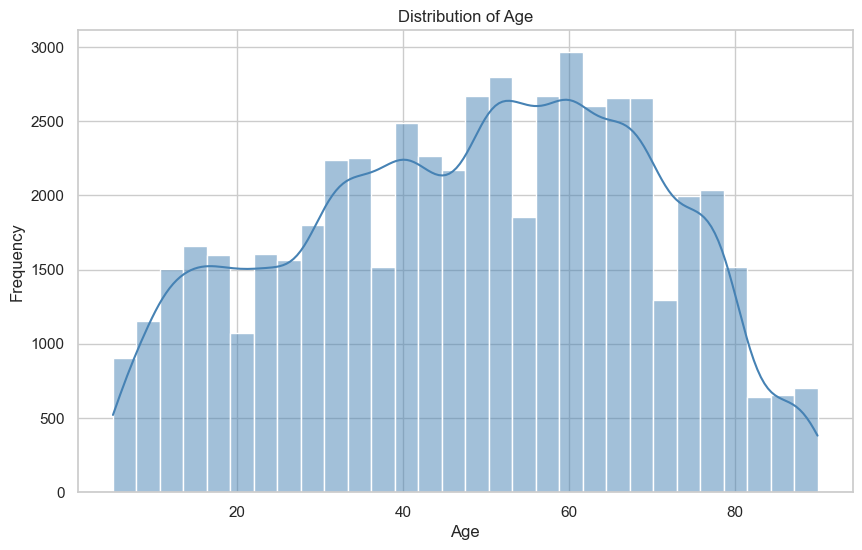

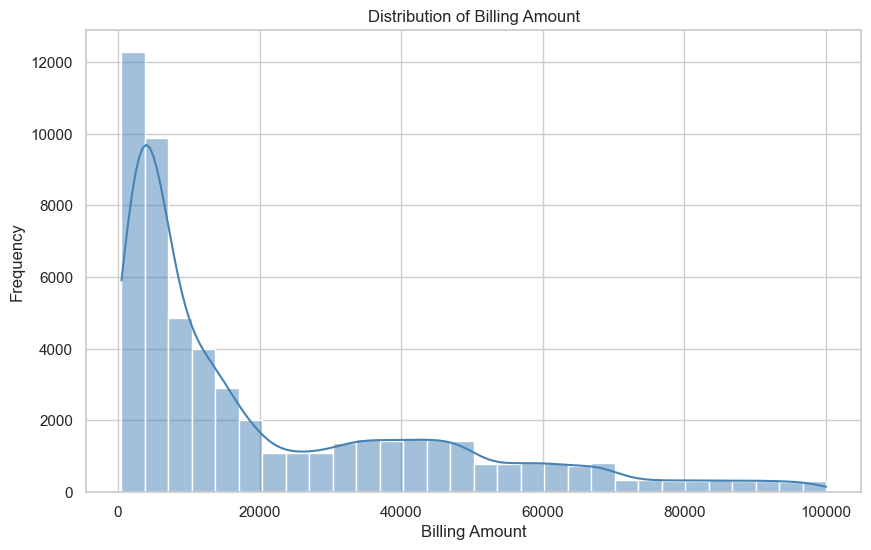

In [60]:
# Visualize distributions for Age and Billing Amount
for col in ['Age', 'Billing Amount']:
    plt.figure()
    sns.histplot(df[col], kde=True, color='steelblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

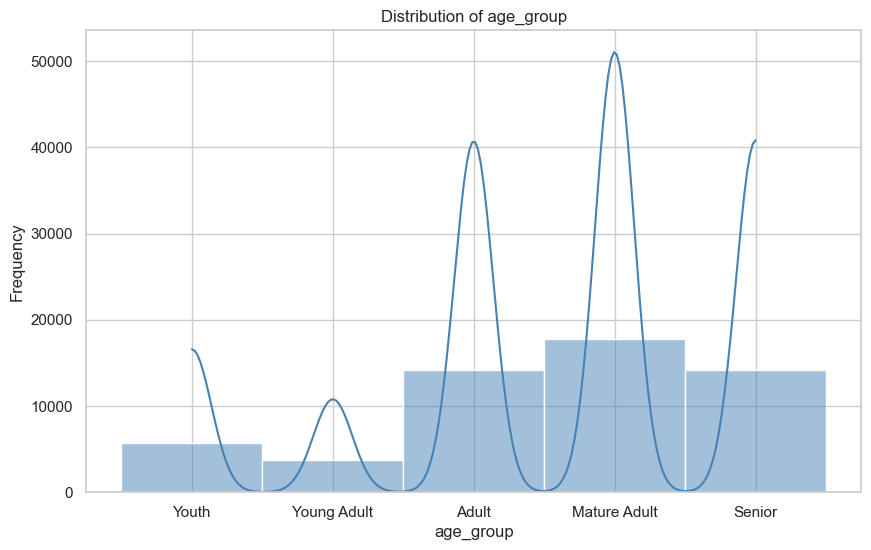

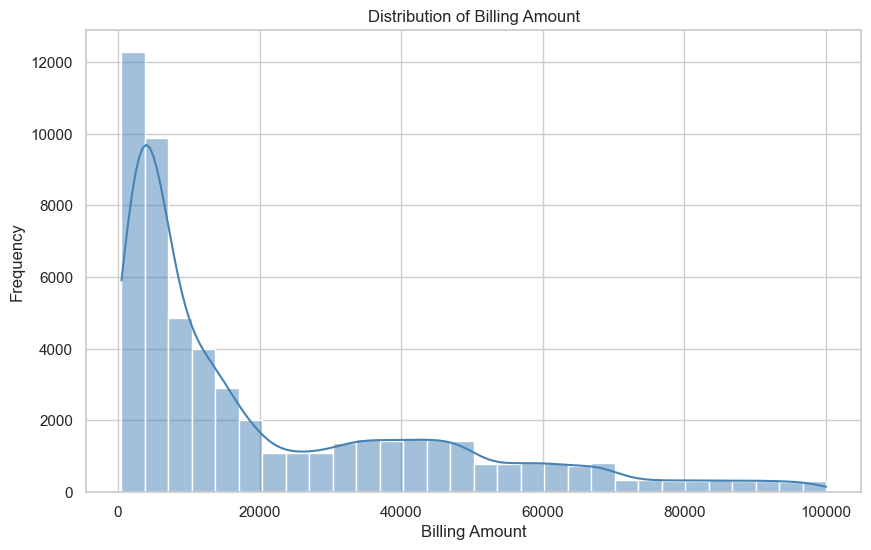

In [48]:
# Visualize distributions for Age and Billing Amount
for col in ['age_group', 'Billing Amount']:
    plt.figure()
    sns.histplot(df[col], kde=True, color='steelblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

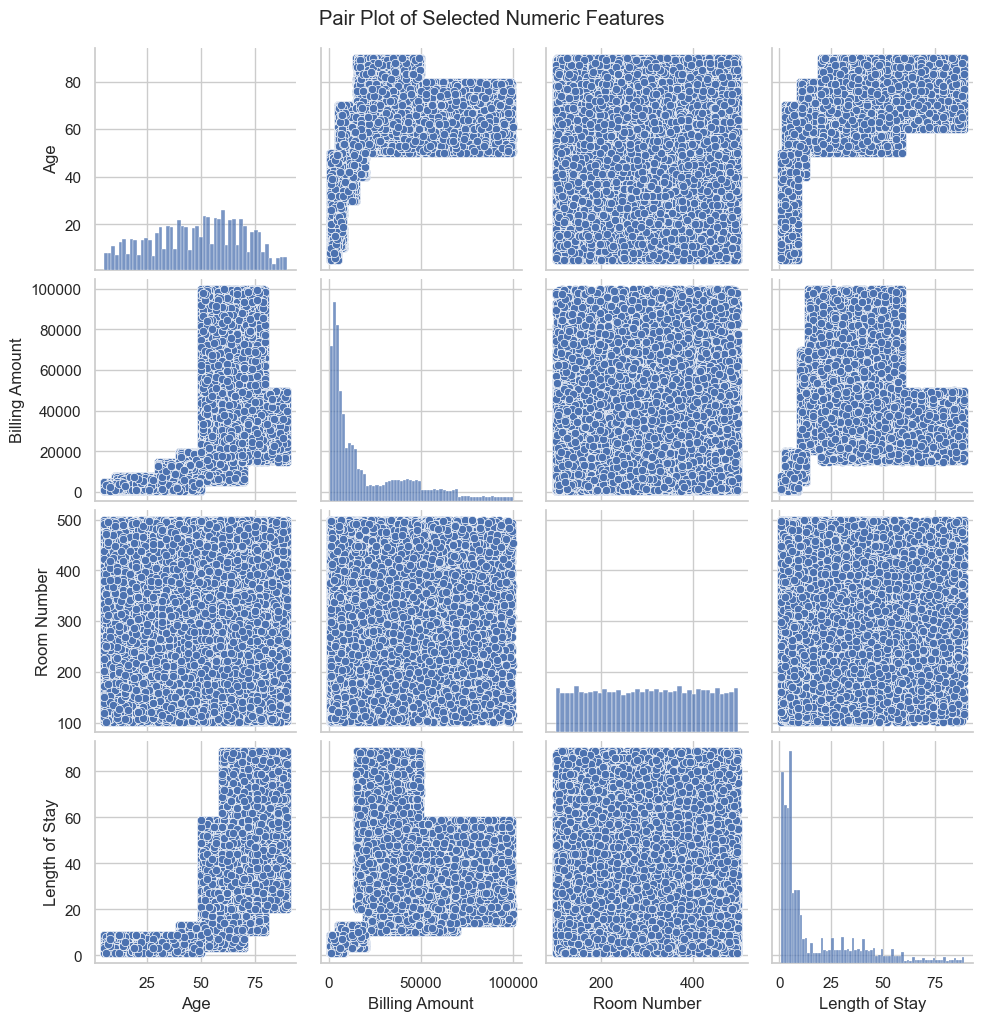

In [64]:
# Generating a pair plot for a subset of numeric features
pairplot_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
if set(pairplot_cols).issubset(numeric_df.columns):
    sns.pairplot(df[pairplot_cols])
    plt.suptitle('Pair Plot of Selected Numeric Features', y=1.02)
    plt.show()
else:
    print('Not all selected columns are present for pair plot.')

Predictive Modeling

Linear Regression R² Score: 0.833
Linear Regression Mean Squared Error: 93634099.183


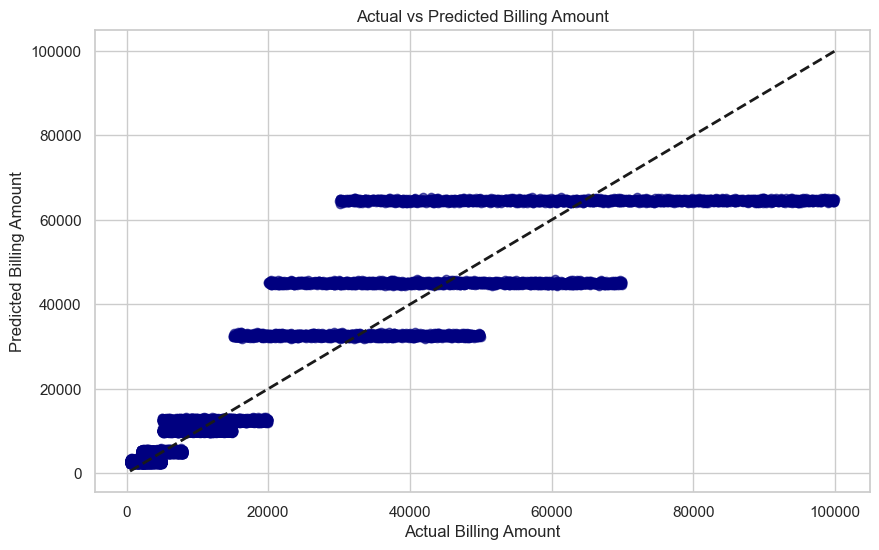

In [65]:
# Prepare the data for predictive modeling

# Drop columns that are unlikely to be useful for prediction (e.g., Name, Doctor, Hospital, Medication, Test Results)
drop_cols = ['Name', 'Doctor', 'Hospital', 'Medication', 'Test Results']
model_df = df.drop(columns=drop_cols, errors='ignore')

# For dates, extract useful features (e.g., year, month) if present
if 'Date of Admission' in model_df.columns:
    model_df['Admission_Year'] = model_df['Date of Admission'].dt.year
    model_df['Admission_Month'] = model_df['Date of Admission'].dt.month
if 'Discharge Date' in model_df.columns:
    model_df['Discharge_Year'] = model_df['Discharge Date'].dt.year
    model_df['Discharge_Month'] = model_df['Discharge Date'].dt.month

# Drop original date columns to avoid high dimensionality
model_df = model_df.drop(columns=['Date of Admission', 'Discharge Date'], errors='ignore')

# Identify target variable and features
target = 'Billing Amount'
X = model_df.drop(columns=[target])
y = model_df[target]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Linear Regression R² Score: {r2:.3f}')
print(f'Linear Regression Mean Squared Error: {mse:.3f}')

# Optional: Plot a scatter plot of actual vs predicted billing amounts
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6, color='navy')
plt.xlabel('Actual Billing Amount')
plt.ylabel('Predicted Billing Amount')
plt.title('Actual vs Predicted Billing Amount')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()